In [25]:
import numpy as np
import matplotlib.pyplot as plt
import math

# -----------------------------
# 1. Load dataset
# -----------------------------
np.random.seed(112230564)
data = np.loadtxt("dataset.txt")

# normalized data

In [26]:
mean = np.mean(data, axis=0)
std = np.std(data, axis=0)
Data = (data - mean) / std


# Distance Euclidean


In [27]:
def euclidean(a, b):
    return math.sqrt(np.sum((a - b) ** 2))

#K-Means implementation

In [28]:
def kmeans_from_scratch(Data, K, max_iters=100, tol=1e-4):

    indices = np.random.choice(len(Data), K, replace=False)
    centers = Data[indices]

    for _ in range(max_iters):

        clusters = [[] for _ in range(K)]

        for point in Data:
            distances = [np.linalg.norm(point - c) for c in centers]
            cluster_id = np.argmin(distances)
            clusters[cluster_id].append(point)

        new_centers = []
        for i in range(K):
            if len(clusters[i]) > 0:
                new_centers.append(np.mean(clusters[i], axis=0))
            else:
                new_centers.append(centers[i])

        new_centers = np.array(new_centers)

        if np.linalg.norm(new_centers - centers) < tol:
            break

        centers = new_centers

    # -------- INERTIA  --------
    inertia = 0
    for i in range(K):
        for point in clusters[i]:
            inertia += np.sum((point - centers[i]) ** 2)

    return clusters, centers, inertia


#Run for different K values

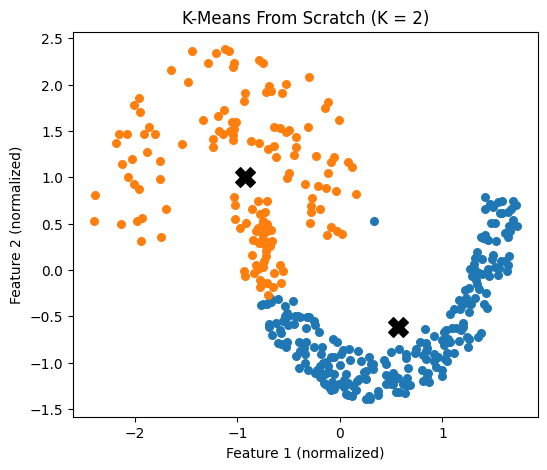

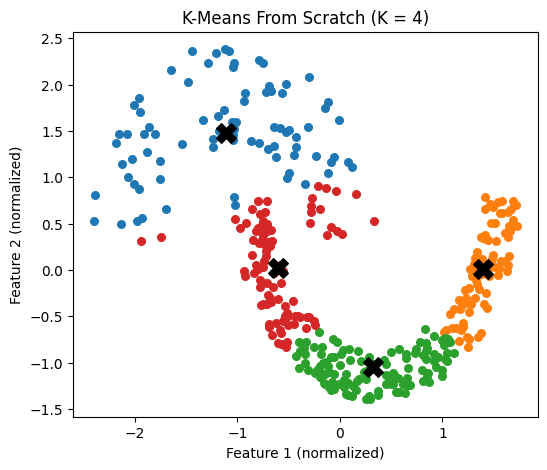

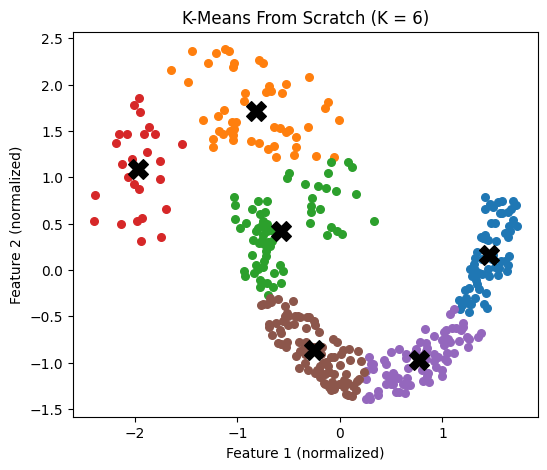

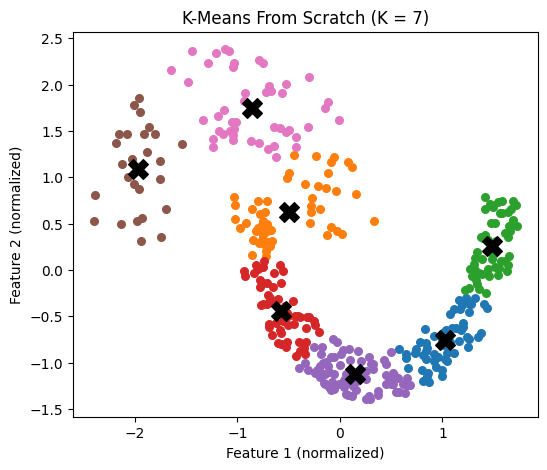

In [29]:
K_values = [2, 4, 6, 7]
inertia_results = []

for K in K_values:
    clusters, centers, inertia = kmeans_from_scratch(Data, K)
    inertia_results.append(inertia)

    # Plot clusters
    plt.figure(figsize=(6, 5))
    for i, cluster in enumerate(clusters):
        cluster = np.array(cluster)
        plt.scatter(cluster[:, 0], cluster[:, 1], s=30)

    plt.scatter(centers[:, 0], centers[:, 1],
                marker='X', s=200, c='black')

    plt.title(f"K-Means From Scratch (K = {K})")
    plt.xlabel("Feature 1 (normalized)")
    plt.ylabel("Feature 2 (normalized)")
    plt.show()


In [30]:
print("Inertia values:")
for k, inert in zip(K_values, inertia_results):
    print(f"K = {k} -> Inertia = {inert:.4f}")

Inertia values:
K = 2 -> Inertia = 322.3389
K = 4 -> Inertia = 133.4784
K = 6 -> Inertia = 71.8954
K = 7 -> Inertia = 56.2375
